# Random Forest - HR Employee Attrition 

**Goal** Train a Random Forest classifier to predict employee attrition, evaluate it, and export the model + preprocessing pipeline so DiCE can generate counterfactual explanations.

----

Outputs saved for Dice:
- *random_forest.pkl* : trained model
- *scaler.pkl*: StandardScaler fitted on training data
- *feature_names.pkl* : Ordered list of features names
- *label_encoders.pkl*: LabelEncoders for categorical features


# 1. Data Load
## 1.1.Paths 
Since i like to work on my pc i will set my paths , but also leave (later) a cell to run in google collab. 
If you want to use your own paths. You can change it in here.

In [12]:
import os 

BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
DATA = os.path.join(BASE_PATH, 'data', 'processed')
MODELS_PATH       = os.path.join(BASE_PATH, 'data', 'models', 'XGBoost')

os.makedirs(MODELS_PATH, exist_ok=True)

print(f'Base:         {BASE_PATH}')
print(f'Preprocessed: {DATA}')
print(f'Models out:   {MODELS_PATH}')


Base:         c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project
Preprocessed: c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\processed
Models out:   c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost


## 1.2.Imports
some basic libraries to start with

In [13]:
'''
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
'''

'\n%pip install numpy\n%pip install pandas\n%pip install matplotlib\n%pip install scikit-learn\n'

In [14]:
SEED = 48

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
np.random.seed(SEED)

print('✅ Libraries loaded.')

✅ Libraries loaded.


## 1.3.Load Preprocessed Data

In [15]:
X_train = np.load(os.path.join(DATA,'X_train.npy'))
X_val   = np.load(os.path.join(DATA,'X_val.npy'))
X_test  = np.load(os.path.join(DATA,'X_test.npy'))

y_train = np.load(os.path.join(DATA,'y_train.npy'))
y_val   = np.load(os.path.join(DATA,'y_val.npy'))
y_test  = np.load(os.path.join(DATA,'y_test.npy'))

with open(os.path.join(DATA, 'scaler.pkl'),         'rb') as f: scaler         = pickle.load(f)
with open(os.path.join(DATA, 'feature_names.pkl'),  'rb') as f: feature_names  = pickle.load(f)
with open(os.path.join(DATA, 'label_encoders.pkl'), 'rb') as f: label_encoders = pickle.load(f)

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}    |  y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print(f'\nFeatures ({len(feature_names)}): {feature_names}')
print(f'\nClass distribution in train — 0 (No): {(y_train==0).sum()} | 1 (Yes): {(y_train==1).sum()}')

X_train: (1029, 30)  |  y_train: (1029,)
X_val:   (220, 30)    |  y_val:   (220,)
X_test:  (221, 30)   |  y_test:  (221,)

Features (30): ['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Class distribution in train — 0 (No): 863 | 1 (Yes): 166


# 2. Tree Model
## 2.1.Training the Random Forest Classifier
Quick note we are going to use class-weight='balanced' to handle the class imbalance in the dataset. This will help the model to pay more attention to the minority class (attrition) during training.

We have this difference in distribution in the target variable in train and test sets, but we will handle it with class weights in the model.

Class distribution in train — 0 (No): 863 | 1 (Yes): 166
Class distribution in test — 0 (No): 185 | 1 (Yes): 36

In [16]:
#%pip install xgboost
THRESHOLD = 0.2

In [17]:

from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # equivalente a class_weight='balanced'

xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,  # maneja el desbalance
    random_state=SEED,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)
print('✅ XGBoost trained.')

✅ XGBoost trained.


## 2.2. Model Evaluation
warning... look at teh f1 its the most important metric here, because of the class imbalance. We want to make sure that we are not just predicting the majority class (no attrition) all the time.

IMPORTANT!!!!!!!!!!
the threshold is 0.2!

In [18]:
y_val_proba  = xgb.predict_proba(X_val)[:, 1]
y_val_pred   = (y_val_proba  >= THRESHOLD).astype(int)

y_test_proba = xgb.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= THRESHOLD).astype(int)

acc          = accuracy_score(y_test, y_test_pred)
f1_weighted  = f1_score(y_test, y_test_pred, average='weighted')
f1_attrition = f1_score(y_test, y_test_pred, pos_label=1)

print('=== VALIDATION SET ===')
print(classification_report(y_val, y_val_pred, target_names=['No (0)', 'Yes (1)']))

print('=== TEST SET ===')
print(classification_report(y_test, y_test_pred, target_names=['No (0)', 'Yes (1)']))
print(f'Accuracy:          {acc:.3f}')
print(f'F1 (weighted):     {f1_weighted:.3f}')
print(f'F1 (Attrition=1):  {f1_attrition:.3f}  ← most important')

=== VALIDATION SET ===
              precision    recall  f1-score   support

      No (0)       0.87      0.90      0.89       185
     Yes (1)       0.38      0.31      0.34        35

    accuracy                           0.81       220
   macro avg       0.63      0.61      0.62       220
weighted avg       0.80      0.81      0.80       220

=== TEST SET ===
              precision    recall  f1-score   support

      No (0)       0.90      0.92      0.91       185
     Yes (1)       0.53      0.47      0.50        36

    accuracy                           0.85       221
   macro avg       0.72      0.70      0.70       221
weighted avg       0.84      0.85      0.84       221

Accuracy:          0.846
F1 (weighted):     0.842
F1 (Attrition=1):  0.500  ← most important


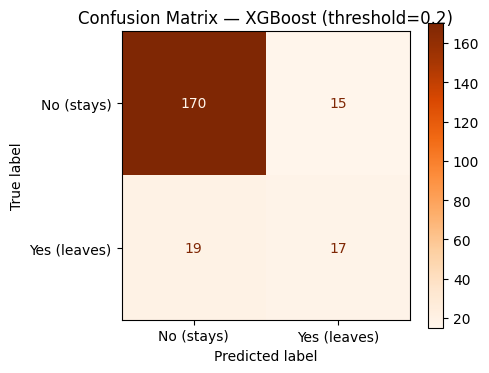

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['No (stays)', 'Yes (leaves)'],
    cmap='Oranges', ax=ax
)
ax.set_title(f'Confusion Matrix — XGBoost (threshold={THRESHOLD})')
plt.tight_layout()
plt.show()

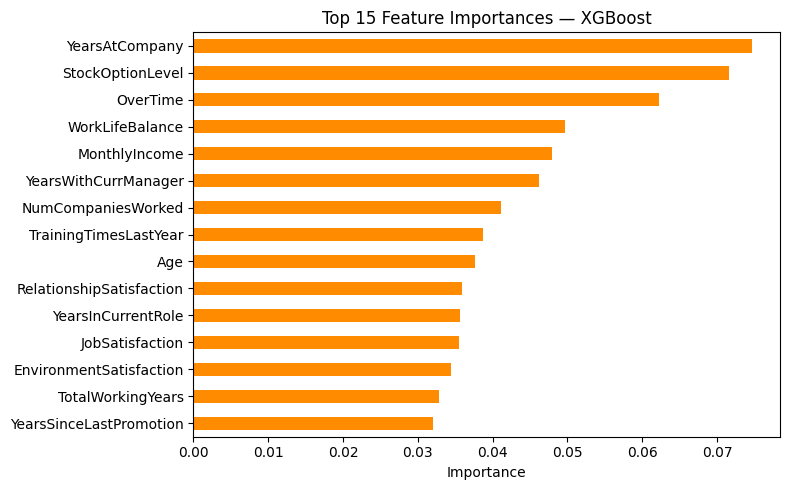

In [20]:
importances = pd.Series(xgb.feature_importances_, index=feature_names)
top15 = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15.sort_values().plot(kind='barh', color='darkorange', ax=ax)
ax.set_title('Top 15 Feature Importances — XGBoost')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# 3. Save Locally for DiCE
We are going to save it in data/models 

In [21]:
artifacts = {
    'xgboost.pkl':        xgb,
    'feature_names.pkl':  feature_names,
    'label_encoders.pkl': label_encoders,
    'scaler.pkl':         scaler,
}

for filename, obj in artifacts.items():
    path = os.path.join(MODELS_PATH, filename)
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    print(f'✅ {path}')

print('\n📦 All artifacts saved locally.')

✅ c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost\xgboost.pkl
✅ c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost\feature_names.pkl
✅ c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost\label_encoders.pkl
✅ c:\Users\kamil\Desktop_new\Local\Universidad\H512 Current Trends\infoh512-project\data\models\XGBoost\scaler.pkl

📦 All artifacts saved locally.


## 3.1.Optional Upload to Google Drive


In [22]:
try:
    from google.colab import drive as _drive
    _drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DRIVE_MODELS = '/content/drive/MyDrive/Current_Trends_in_AI/models'
    os.makedirs(DRIVE_MODELS, exist_ok=True)
    for fname in ['random_forest.pkl', 'scaler.pkl', 'feature_names.pkl', 'label_encoders.pkl']:
        shutil.copy(os.path.join(MODELS_PATH, fname), os.path.join(DRIVE_MODELS, fname))
        print(f'☁️  {fname}')
else:
    print('Not in Colab — skipping Drive upload.')

Not in Colab — skipping Drive upload.
